<div style="
    background: linear-gradient(135deg, #102a43 0%, #1f4e5f 52%, #2f7d73 100%);
    padding: 38px 34px 30px 34px;
    border-radius: 14px;
    margin: 8px 0 22px 0;
    box-shadow: 0 10px 28px rgba(16, 42, 67, 0.28);
    border: 1px solid rgba(255,255,255,0.16);
    text-align: center;
">
    <p style="color: rgba(255,255,255,0.72); margin: 0 0 10px 0; font-size: 12px; letter-spacing: 4px; text-transform: uppercase;">PHY-3202 · Laboratoire 03</p>
    <h1 style="color: white; margin: 0; font-size: 34px; font-weight: 400; letter-spacing: 1px;">Évolution : échantillon i.i.d. et auto-organisation</h1>
    <div style="width: 72px; height: 3px; background: #e7a23b; margin: 18px auto 14px auto; border-radius: 3px;"></div>
    <p style="color: rgba(255,255,255,0.92); margin: 0; font-size: 17px;">De la journée simulée aux premières séries temporelles</p>
</div>

<div style="
    background: var(--vscode-textBlockQuote-background, rgba(31,78,95,0.10));
    border-left: 6px solid #1f4e5f;
    border-radius: 9px;
    padding: 16px 20px;
    margin: 0 0 18px 0;
">
<strong>Auteur :</strong> Alex Baker &nbsp; · &nbsp; <strong>Superviseur :</strong> Patrick Desrosiers
</div>

## Fil directeur

Les carnets 01 et 02 couvraient les outils d'analyse puis le dispatch et ses
transitions sur un réseau figé. `cascade.py` a ensuite ajouté la boucle de
pannes journalière. Ce carnet orchestre tout ça sur de nombreux jours, dans
les deux modes que Patrick a approuvés : un échantillon i.i.d. à charge fixée
(validation contre Carreras et al., 2002), et une dynamique d'auto-organisation
où la demande croît et le réseau se renforce en retour (Carreras et al., 2004).

<div style="
    background: var(--vscode-editor-inactiveSelectionBackground, rgba(231,162,59,0.12));
    border: 1px solid rgba(231,162,59,0.55);
    border-radius: 9px;
    padding: 16px 20px;
    margin: 18px 0 6px 0;
    color: var(--vscode-editor-foreground, inherit);
">
<strong style="color: #1f4e5f;">Au programme</strong>
<ol style="margin: 10px 0 0 20px; padding: 0; line-height: 1.7;">
<li>Un jour sans surprise — le cas p0 = p1 = g = 0</li>
<li>L'échantillon à charge fixée — mode <code>independant</code></li>
<li>Trouver, puis suivre, la marge critique — mode <code>auto_organise</code></li>
<li>Les deux régimes, côte à côte</li>
</ol>
</div>

<div style="text-align: center; color: var(--vscode-descriptionForeground, #6b7c85); font-size: 12px; margin-top: 18px;">
<strong>Question directrice :</strong> à quoi ressemblent les séries que le fil B recevra, et que disent-elles déjà avant toute analyse entropique ?
</div>

In [1]:
import numpy as np

from cascade_entropy import evolution, figures
from cascade_entropy.dispatch import demande_uniforme, resoudre
from cascade_entropy.reseau import arbre, limites_par_niveau, matrice_de_flux

figures.appliquer_style()

GRAINE = 20260915
P_C = 2623.9            # capacité totale de production, valeur publiée
CIBLE_SECONDE = 1.45    # niveau de charge visé pour la saturation des lignes

# Même réseau calibré qu'au carnet 02 : rien n'est reconstruit différemment.
reseau = arbre(4)
A = matrice_de_flux(reseau)
p_max = np.full(reseau.generateurs.size, P_C / reseau.generateurs.size)
base = limites_par_niveau(reseau)
facteur = resoudre(reseau, demande_uniforme(reseau, CIBLE_SECONDE * P_C),
                   limites=base, puissance_max=p_max, A=A).taux_maximal
limites = base * facteur

DEMANDE_INITIALE = 0.8 * P_C   # P_D/P_C = 0,8, comme la « charge modérée » du carnet 02
G, P0, P1 = 0.9, 0.01, 1.0     # g = 0,9 (<-> 1,9 chez Carreras), p0 modeste, p1 déterministe

print(f"{reseau.n_noeuds} nœuds, {reseau.n_lignes} lignes, "
      f"{reseau.generateurs.size} générateurs")
print(f"facteur d'échelle (repris du carnet 02) : {facteur:.4f}")
print(f"demande moyenne retenue : {DEMANDE_INITIALE:.1f}  (P_D/P_C = 0,8)")

46 nœuds, 45 lignes, 12 générateurs
facteur d'échelle (repris du carnet 02) : 0.0607
demande moyenne retenue : 2099.1  (P_D/P_C = 0,8)


<div style="
    background: linear-gradient(135deg, #1f4e5f 0%, #2f7d73 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(31,78,95,0.20);
">
    <p style="color: #dcefeb; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 01 · Validation</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Un jour sans surprise</h2>
</div>

`evolution.simuler()` enveloppe `cascade.journee()`, qui enveloppe
`dispatch.resoudre()`. Avant de faire confiance à l'empilement, on vérifie
qu'il se réduit exactement au morceau du dessous quand on désactive tout
l'aléatoire — c'est le premier critère de validation posé pour ce module.

<div style="background: #f8f4ea; color: #1f2933; border-left: 4px solid #e7a23b; padding: 12px 16px; border-radius: 7px; margin-top: 14px;">
<strong>Repère de lecture.</strong> Comme au carnet 02, on commence par un cas qu'on peut vérifier soi-même avant de faire confiance au reste.
</div>

In [1]:
parametres_nul = evolution.Parametres(
    mode="independant", demande_initiale=DEMANDE_INITIALE,
    puissance_max=p_max, g=0.0, p0=0.0, p1=0.0, limites=limites,
)
rng_nul = np.random.default_rng(GRAINE)
un_jour = evolution.simuler(reseau, 1, parametres_nul, rng_nul)[0]

demande_directe = demande_uniforme(reseau, DEMANDE_INITIALE)
solution_directe = resoudre(reseau, demande_directe, limites=limites, puissance_max=p_max)

print("Un jour, g = p0 = p1 = 0 : aucune avarie, aucune fluctuation.")
print(f"  délestage (journee) : {un_jour.delestage_total:.6f}")
print(f"  délestage (resoudre): {solution_directe.delestage_total:.6f}")
print(f"  M_max (journee)     : {un_jour.taux_maximal:.6f}")
print(f"  M_max (resoudre)    : {solution_directe.taux_maximal:.6f}")
print(f"  n_lignes_en_service : {un_jour.n_lignes_en_service} / {reseau.n_lignes}")

Un jour, g = p0 = p1 = 0 : aucune avarie, aucune fluctuation.
  délestage (journee) : 0.000000
  délestage (resoudre): 0.000000
  M_max (journee)     : 0.656804
  M_max (resoudre)    : 0.656804
  n_lignes_en_service : 45 / 45


Les deux colonnes coïncident au bit près — attendu, puisque avec `g = 0` le
tirage `rng.uniform(1, 1, ...)` renvoie exactement 1 partout, et qu'avec
`p0 = p1 = 0` aucune ligne ne peut jamais tomber. `evolution.simuler()` ne
fait donc rien de plus que `dispatch.resoudre()` tant qu'on ne lui donne pas
de raison de faire autre chose.

<div style="
    background: linear-gradient(135deg, #2f7d73 0%, #4f9d8b 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(47,125,115,0.20);
">
    <p style="color: #e6f5f0; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 02 · Mode indépendant</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">L'échantillon à charge fixée</h2>
</div>

Le réseau et sa capacité restent fixes ; seuls la demande (fluctuation `g`),
les avaries accidentelles (`p0`) et la cascade (`p1`) varient, de façon i.i.d.,
d'un jour à l'autre. C'est l'équivalent des « 60 000 cases by random variation
of the loads » de Carreras et al. (2002) — un échantillon Monte-Carlo à charge
fixée, pas une dynamique temporelle.

<div style="background: #eef7f4; color: #1f2933; border-left: 4px solid #2f7d73; padding: 12px 16px; border-radius: 7px; margin-top: 14px;">
<strong>Idée physique.</strong> g = 0,9 ici correspond à g = 1,9 chez Carreras — c'est délibérément une fluctuation forte, qui garantit assez de jours avec délestage pour en tirer une distribution lisible sans des centaines de milliers de tirages.
</div>

In [1]:
N_JOURS_INDEP = 2000
parametres_indep = evolution.Parametres(
    mode="independant", demande_initiale=DEMANDE_INITIALE,
    puissance_max=p_max, g=G, p0=P0, p1=P1, limites=limites,
)
rng_indep = np.random.default_rng(GRAINE)
jours_indep = evolution.simuler(reseau, N_JOURS_INDEP, parametres_indep, rng_indep)
series_indep = evolution.series(jours_indep)

frac_delestage = float((series_indep["delestage_total"] > 1e-9).mean())
print(f"{N_JOURS_INDEP} jours simulés (mode independant)")
print(f"  jours avec délestage       : {frac_delestage:.1%}")
print(f"  délestage moyen            : {series_indep['delestage_total'].mean():.1f}")
print(f"  délestage maximal observé  : {series_indep['delestage_total'].max():.1f}")
print(f"  M_max moyen                : {series_indep['taux_maximal'].mean():.3f}")
print(f"  nombre effectif moyen      : {np.nanmean(series_indep['nombre_effectif']):.1f}"
      f"  (sur {reseau.n_lignes} lignes)")

2000 jours simulés (mode independant)
  jours avec délestage       : 82.0%
  délestage moyen            : 171.2
  délestage maximal observé  : 691.2
  M_max moyen                : 0.989
  nombre effectif moyen      : 35.4  (sur 45 lignes)


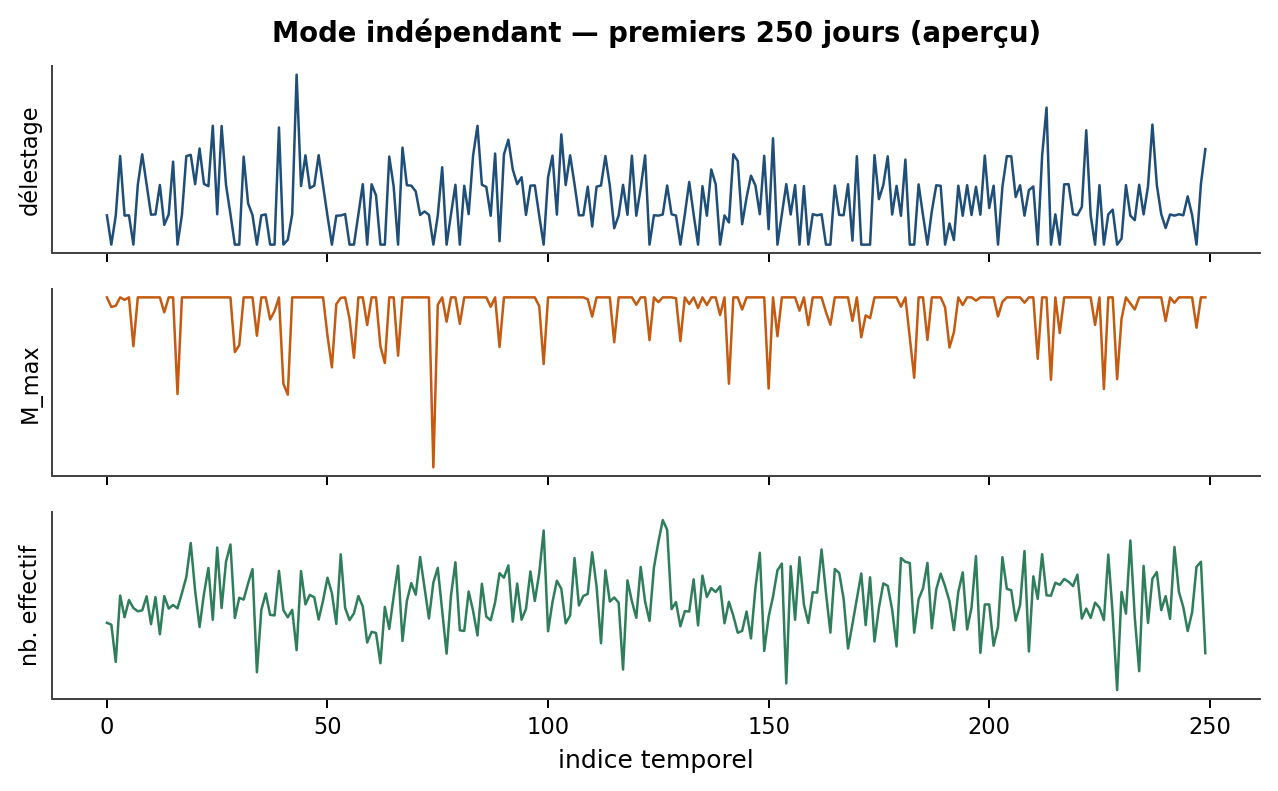

In [1]:
figures.galerie_series(
    {
        "délestage": series_indep["delestage_total"],
        "M_max": series_indep["taux_maximal"],
        "nb. effectif": series_indep["nombre_effectif"],
    },
    n_points=250,
    titre="Mode indépendant — premiers 250 jours (aperçu)",
);

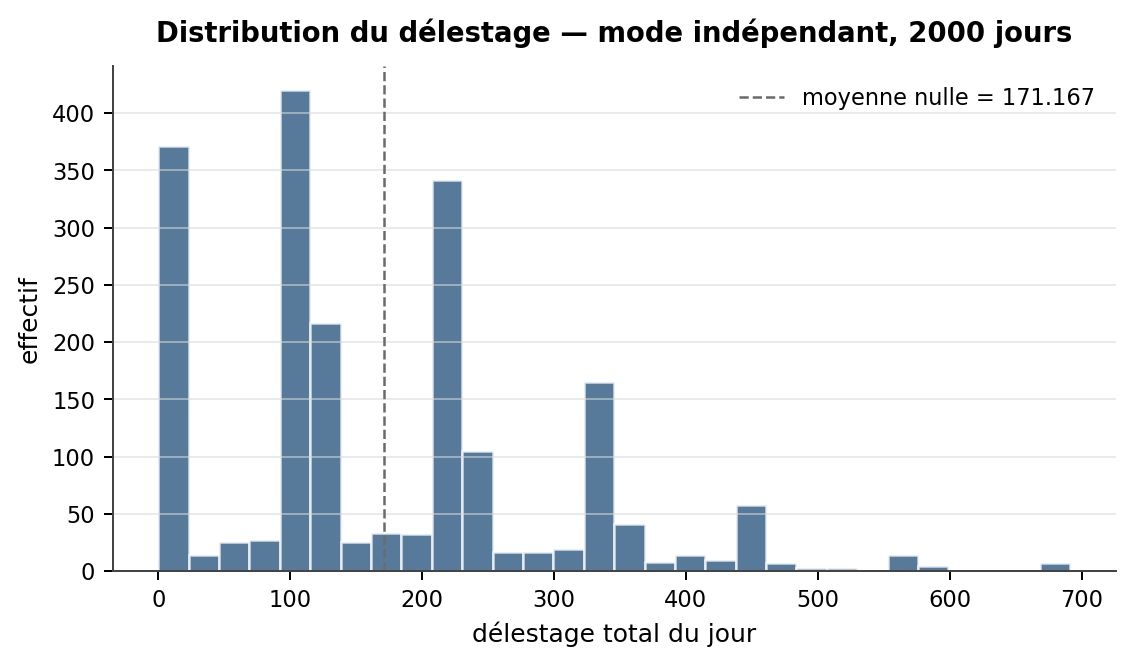

In [1]:
figures.distribution_nulle(
    series_indep["delestage_total"],
    xlabel="délestage total du jour",
    titre=f"Distribution du délestage — mode indépendant, {N_JOURS_INDEP} jours",
);

Deux choses à noter avant d'aller plus loin.

**Sur l'aperçu temporel.** Aucune des trois courbes ne dérive — c'est
exactement la signature d'un échantillon i.i.d. : du bruit autour d'un régime
fixe, sans tendance. C'est voulu pour ce mode, mais ça veut aussi dire qu'une
mesure sensible à l'*ordre* des valeurs (comme l'entropie de permutation que
le fil B appliquera plus tard) n'a ici, par construction, aucune structure
temporelle à détecter. Ce sera le bon test pour voir si une telle mesure sait
rester silencieuse quand il n'y a rien à trouver.

**Sur l'histogramme.** On réutilise `figures.distribution_nulle` comme un
histogramme ordinaire plutôt que comme un test d'hypothèse — « moyenne nulle »
dans la légende désigne ici simplement la moyenne empirique. La forme
multimodale est bien réelle : elle correspond aux différents nombres de
lignes qui cèdent avant que la cascade ne s'arrête, pas à un artefact.

<div style="
    background: linear-gradient(135deg, #244b63 0%, #347b91 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(36,75,99,0.20);
">
    <p style="color: #dceef4; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 03 · Mode auto_organise</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Trouver, puis suivre, la marge critique</h2>
</div>

Ici, la demande croît (`lambda_`), les générateurs sont mis à niveau quand la
marge de génération passe sous `marge_seuil` (Carreras et al., 2004, Éq. 3-4),
et les lignes tombées par surcharge un jour de blackout sont renforcées par
`mu`. On calibre d'abord la capacité de départ pour que la marge initiale soit
proche du seuil — sinon, comme vu précédemment, 3000 jours à 1,8 %/an ne
suffisent pas à faire grand-chose.

<div style="background: #edf5f8; color: #1f2933; border-left: 4px solid #347b91; padding: 12px 16px; border-radius: 7px; margin-top: 14px;">
<strong>Idée physique.</strong> Une fois la marge au seuil, le réseau n'a plus de coussin : chaque petit pas de croissance de la demande doit être compensé presque aussitôt. C'est la signature d'un système qui s'auto-organise à la limite de sa marge critique.
</div>

In [1]:
MARGE_INITIALE = 0.16
MARGE_SEUIL = 0.08
MU = 1.05       # dans [1,01 ; 1,10], Carreras et al. (2004)
K = 0.02        # « a few percent », valeur par défaut proposée
LAMBDA_ = 1.018  # 1,8 %/an

puissance_max_initiale = evolution.puissance_max_pour_marge(
    reseau, DEMANDE_INITIALE, MARGE_INITIALE
)
marge_verifiee = evolution.marge_moyenne(puissance_max_initiale, DEMANDE_INITIALE)
print(f"capacité initiale par générateur : {puissance_max_initiale[0]:.2f}")
print(f"capacité totale installée       : {puissance_max_initiale.sum():.1f}")
print(f"marge initiale visée            : {MARGE_INITIALE:.2%}")
print(f"marge initiale vérifiée         : {marge_verifiee:.2%}")
print(f"seuil de déclenchement          : {MARGE_SEUIL:.2%}")

capacité initiale par générateur : 202.91
capacité totale installée       : 2435.0
marge initiale visée            : 16.00%
marge initiale vérifiée         : 16.00%
seuil de déclenchement          : 8.00%


In [1]:
N_JOURS_AUTO = 3000
parametres_auto = evolution.Parametres(
    mode="auto_organise", demande_initiale=DEMANDE_INITIALE,
    puissance_max=puissance_max_initiale, g=G, p0=P0, p1=P1, limites=limites,
    lambda_=LAMBDA_, k=K, marge_seuil=MARGE_SEUIL, mu=MU,
)
rng_auto = np.random.default_rng(GRAINE)
jours_auto = evolution.simuler(reseau, N_JOURS_AUTO, parametres_auto, rng_auto)
series_auto = evolution.series(jours_auto)

jours_avec_maj = np.flatnonzero(series_auto["n_mises_a_niveau"] > 0)
premier_jour_maj = int(jours_avec_maj[0] + 1) if jours_avec_maj.size else None

print(f"{N_JOURS_AUTO} jours simulés (mode auto_organise)")
print(f"  premier jour avec mise à niveau : {premier_jour_maj}")
print(f"  nombre de mises à niveau        : {int(series_auto['n_mises_a_niveau'].sum())}")
print(f"  capacité installée : {puissance_max_initiale.sum():.1f} -> "
      f"{series_auto['capacite_totale_generateurs'][-1]:.1f}"
      f"  (+{series_auto['capacite_totale_generateurs'][-1] / puissance_max_initiale.sum() - 1:.1%})")
print(f"  marge moyenne       : {series_auto['marge_moyenne'][0]:.2%} -> "
      f"{series_auto['marge_moyenne'][-1]:.2%}")
print(f"  lignes renforcées (jours de blackout, cumulé) : "
      f"{int(series_auto['n_lignes_renforcees'].sum())}")

3000 jours simulés (mode auto_organise)
  premier jour avec mise à niveau : 1462
  nombre de mises à niveau        : 49
  capacité installée : 2435.0 -> 2626.1  (+7.8%)
  marge moyenne       : 15.99% -> 8.04%
  lignes renforcées (jours de blackout, cumulé) : 125


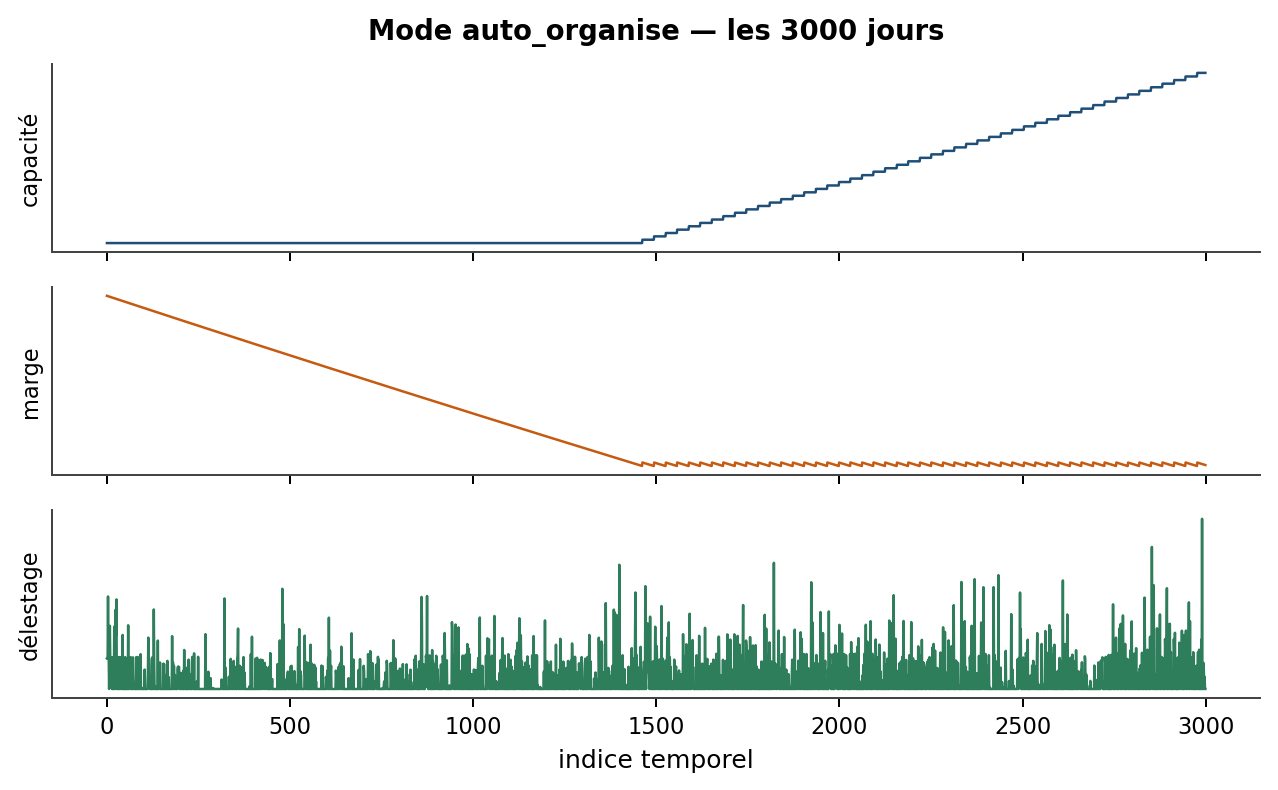

In [1]:
figures.galerie_series(
    {
        "capacité": series_auto["capacite_totale_generateurs"],
        "marge": series_auto["marge_moyenne"],
        "délestage": series_auto["delestage_total"],
    },
    n_points=N_JOURS_AUTO,
    titre="Mode auto_organise — les 3000 jours",
);

Exactement le scénario anticipé : marge plate autour de 16 % pendant environ
1460 jours (la croissance seule n'a pas encore rattrapé l'écart), puis le
seuil de 8 % est atteint et le réseau se met à « surfer » dessus — 49 petites
mises à niveau, presque une par ligne de la marge perdue à la croissance,
jusqu'à la fin de la simulation. La capacité installée ne grimpe que
d'environ 8 % en tout : c'est l'auto-organisation critique de Carreras et al.
(2004) en modèle réduit, pas encore leurs dizaines de milliers de jours en
régime stationnaire — ce passage à l'échelle reste noté pour le rapport
final.

<div style="
    background: linear-gradient(135deg, #8b5e34 0%, #b47a3c 100%);
    padding: 18px 24px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    border-left: 6px solid #f1c36b;
    box-shadow: 0 6px 18px rgba(139,94,52,0.20);
">
    <p style="color: #fff1d4; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Étape 04 · Comparaison</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Les deux régimes, côte à côte</h2>
</div>

Un premier regard, avant tout traitement par le fil B : les deux modes
produisent-ils des jours qui se ressemblent, ou le mécanisme d'auto-organisation
change-t-il déjà quelque chose de visible à l'œil nu ?

<div style="background: #fbf5ec; color: #1f2933; border-left: 4px solid #b47a3c; padding: 12px 16px; border-radius: 7px; margin-top: 14px;">
<strong>Question d'observation.</strong> Le renforcement sélectif des lignes (mu) peut-il stabiliser le réseau davantage qu'une simple marge de production plus confortable ?
</div>

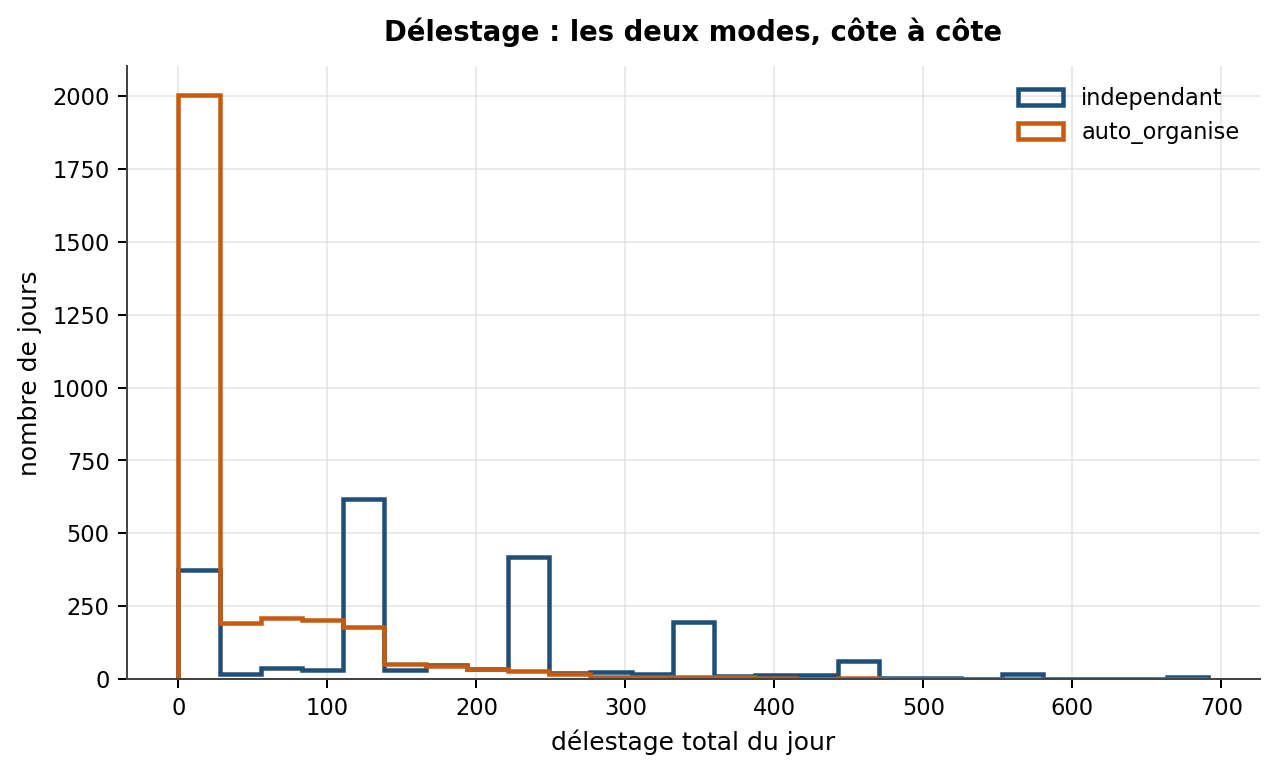

In [1]:
figures.distributions_comparees(
    {"independant": series_indep["delestage_total"],
     "auto_organise": series_auto["delestage_total"]},
    xlabel="délestage total du jour",
    titre="Délestage : les deux modes, côte à côte",
);

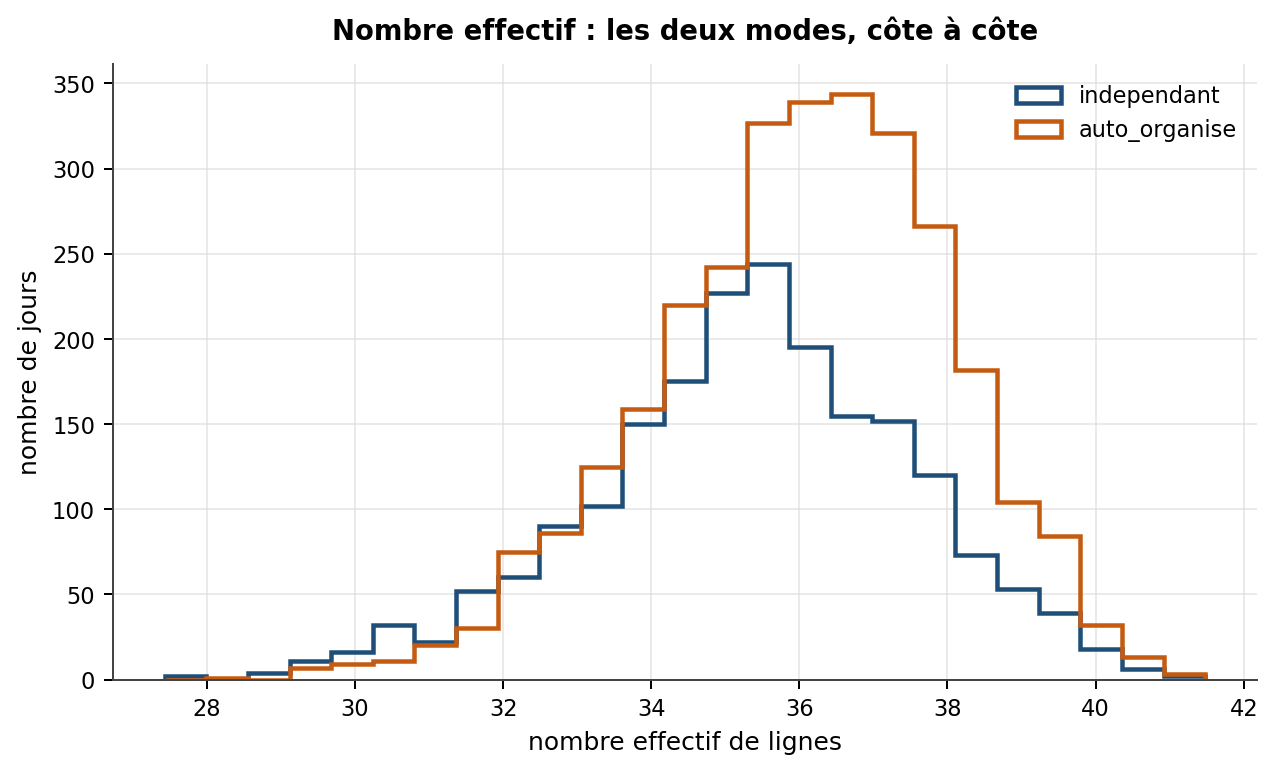

In [1]:
figures.distributions_comparees(
    {"independant": series_indep["nombre_effectif"],
     "auto_organise": series_auto["nombre_effectif"]},
    xlabel="nombre effectif de lignes",
    titre="Nombre effectif : les deux modes, côte à côte",
);

Le délestage de `auto_organise` est beaucoup plus concentré près de zéro que
celui de `independant`, malgré une marge de génération initiale plus mince
(16 % contre 25 % en continu côté `independant`). La différence ne vient donc
pas d'une capacité de production plus confortable — elle vient probablement
du renforcement ciblé des lignes (`mu`), qui n'existe que côté
`auto_organise` : les lignes qui ont déjà cédé une fois deviennent plus
difficiles à refaire céder. C'est une observation, pas une conclusion ferme —
les deux modes diffèrent sur plus d'un paramètre à la fois (la capacité
installée n'est pas identique non plus), donc isoler la cause exacte
demanderait une comparaison contrôlée dédiée. Le nombre effectif, lui, ne
bouge que modestement entre les deux modes.

Ce que ce carnet ne fait pas encore : appliquer une mesure sensible à l'ordre
temporel (entropie de permutation) à ces deux séries pour vérifier si
l'indépendance des jours, à elle seule, l'empêche de voir quoi que ce soit —
c'est précisément la question qui a motivé la construction des deux modes, et
elle revient au fil B.

In [1]:
from pathlib import Path

dossier = Path("data")
chemin_indep = dossier / "evolution_independant.npz"
chemin_auto = dossier / "evolution_auto_organise.npz"
evolution.ecrire(series_indep, chemin_indep)
evolution.ecrire(series_auto, chemin_auto)

print(f"écrit : {chemin_indep}")
print(f"écrit : {chemin_auto}")
print(f"clés disponibles : {list(series_auto.keys())}")

écrit : data/evolution_independant.npz
écrit : data/evolution_auto_organise.npz
clés disponibles : ['jour', 'delestage_total', 'taux_maximal', 'nombre_effectif', 'n_lignes_en_service', 'capacite_totale_generateurs', 'marge_moyenne', 'n_mises_a_niveau', 'n_lignes_renforcees']


<div style="
    background: linear-gradient(135deg, #102a43 0%, #1f4e5f 100%);
    padding: 22px 26px;
    border-radius: 10px;
    margin: 34px 0 18px 0;
    border-left: 6px solid #e7a23b;
    box-shadow: 0 6px 18px rgba(16,42,67,0.22);
">
    <p style="color: #dcefeb; margin: 0 0 5px 0; font-size: 12px; letter-spacing: 2px; text-transform: uppercase;">Bilan · Reproductibilité</p>
    <h2 style="color: white; margin: 0; font-weight: 400;">Où en est le projet</h2>
</div>

<div style="background: #f3f7f6; color: #1f2933; border: 1px solid #c9ddda; border-radius: 9px; padding: 16px 20px;">
<p><strong>En place et validé</strong> — les quatre modules du fil A (<code style="color: #1f4e5f; background: #dcefeb; padding: 1px 4px; border-radius: 3px;">reseau</code>, <code style="color: #1f4e5f; background: #dcefeb; padding: 1px 4px; border-radius: 3px;">dispatch</code>, <code style="color: #1f4e5f; background: #dcefeb; padding: 1px 4px; border-radius: 3px;">cascade</code>, <code style="color: #1f4e5f; background: #dcefeb; padding: 1px 4px; border-radius: 3px;">evolution</code>), les deux modes de simulation, et l'export vers le fil B.</p>
<p><strong>Reproduit</strong> — le mode auto_organise entre en auto-organisation exactement là où le calcul l'annonçait (jour 1462), et s'y maintient par petits renforts, sans qu'aucune de ces deux choses n'ait été programmée directement.</p>
<p><strong>Calibré, et signalé comme tel</strong> — la marge initiale (16 %) et le seuil (8 %) sont choisis pour que le mécanisme se déclenche plusieurs fois sur 3000 jours ; l'échelle complète de Carreras et al. (dizaines de milliers de jours, transitoire retiré) reste un objectif du rapport final, pas de cette démonstration.</p>
<p><strong>Observé, à creuser</strong> — le mode auto_organise déleste moins que le mode independant malgré une marge de départ plus mince ; le renforcement des lignes (mu) en est le suspect le plus probable, pas encore la conclusion.</p>
<p style="margin-bottom: 0;"><strong>Prochaine étape</strong> — le fil B : appliquer l'entropie de permutation aux deux séries de délestage pour vérifier si l'indépendance des jours la rend aveugle, comme la symétrie des <em>m!</em> ordres également probables le laisse prévoir.</p>
</div>

<div style="text-align: center; color: var(--vscode-descriptionForeground, #6b7c85); font-size: 12px; margin-top: 16px;">
<strong>De la journée au régime :</strong> deux mécanismes, deux manières de perdre l'indépendance.
</div>